# **Imports**

In [1]:
#@title Imports

import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.transforms as transforms
import torchvision.datasets as dset
import torchvision.utils as vutils
import matplotlib.pyplot as plt
from matplotlib import animation

In [2]:
!pip freeze > requirements.txt

# **Configurations**

In [3]:
#Constants and hyperparameters for the model, training process, and dataset are defined.
DATA_PATH = '/kaggle/working/'
BATCH_SIZE = 128
IMAGE_CHANNEL = 1
Z_DIM = 100
G_HIDDEN = 64
X_DIM = 64
D_HIDDEN = 64
EPOCH_NUM = 5
REAL_LABEL = 1
FAKE_LABEL = 0
lr = 2e-4
seed = 1

## **CUDA Availability Check and Device Setup**

In [4]:
CUDA = False
CUDA = CUDA and torch.cuda.is_available()
print("PyTorch version: {}".format(torch.__version__))
if CUDA:
    print("CUDA version: {}\n".format(torch.version.cuda))

if CUDA:
    torch.cuda.manual_seed(seed) # reproducibility for any GPU action (weight init., augment, dropout, etc.)
    
device = torch.device("cuda:0" if CUDA else "cpu")
cudnn.benchmark = True # can f*up reproducibility. (for cuda gpu optimization)

PyTorch version: 2.10.0+cu128


# **Preprocessing**

In [5]:
# Load the MNIST dataset with transformations
dataset = dset.MNIST(root=DATA_PATH, download=True,
                     transform=transforms.Compose([
                     transforms.Resize(X_DIM),
                     transforms.ToTensor(),
                     transforms.Normalize((0.5,), (0.5,))
                     ]))

# Create a DataLoader for the dataset
dataloader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE,
                                         shuffle=True, num_workers=2)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.43MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.9MB/s]


## **Visualize**

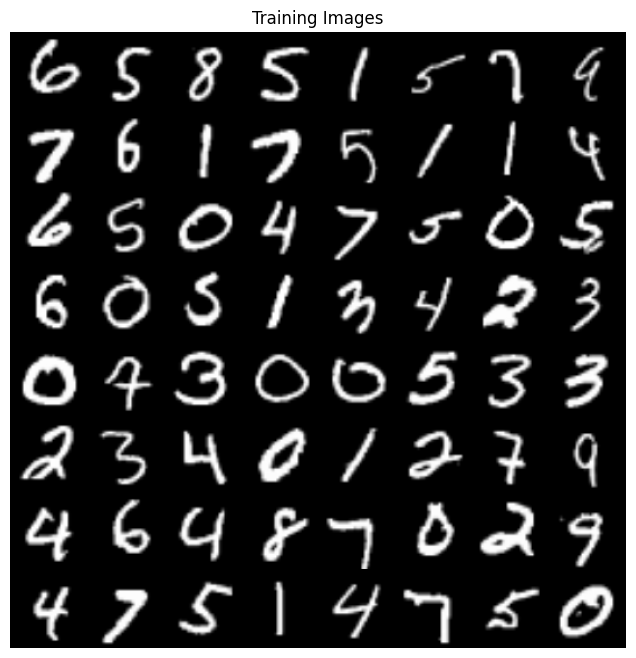

In [6]:
# Display: Visualizes a batch of real images from the dataset.
real_batch = next(iter(dataloader))
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Training Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=2, normalize=True).cpu(),(1,2,0)))

# **Generator Network**

In [7]:
# Generator: Defines the Generator network architecture using transposed convolutions
# to generate images from random noise.

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # input layer
            nn.ConvTranspose2d(Z_DIM, G_HIDDEN * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 8),
            nn.ReLU(True),
            # 1st hidden layer
            nn.ConvTranspose2d(G_HIDDEN * 8, G_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 4),
            nn.ReLU(True),
            # 2nd hidden layer
            nn.ConvTranspose2d(G_HIDDEN * 4, G_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN * 2),
            nn.ReLU(True),
            # 3rd hidden layer
            nn.ConvTranspose2d(G_HIDDEN * 2, G_HIDDEN, 4, 2, 1, bias=False),
            nn.BatchNorm2d(G_HIDDEN),
            nn.ReLU(True),
            # output layer
            nn.ConvTranspose2d(G_HIDDEN, IMAGE_CHANNEL, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, input):
        return self.main(input)

# **Discriminator Network**

In [8]:
# Discriminator: Defines the Discriminator network architecture using
# convolutions to classify real and fake images.

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # 1st layer
            nn.Conv2d(IMAGE_CHANNEL, D_HIDDEN, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 2nd layer
            nn.Conv2d(D_HIDDEN, D_HIDDEN * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # 3rd layer
            nn.Conv2d(D_HIDDEN * 2, D_HIDDEN * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # 4th layer
            nn.Conv2d(D_HIDDEN * 4, D_HIDDEN * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(D_HIDDEN * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # output layer
            nn.Conv2d(D_HIDDEN * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, input):
        return self.main(input).view(-1, 1).squeeze(1)

# **Instantiate Networks**

### **Weight Initialization Function**

In [9]:
# Function to initialize weights of the network
# layers to ensure stable training of the neural networks.

def weights_init(m):
    classname = m.__class__.__name__
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.normal_(m.weight, 0.0, 0.02) # ~Normal(mean = 0, std = 0.02)
    elif isinstance(m, nn.BatchNorm2d):
        nn.init.normal_(m.weight, 1.0, 0.02) # ~Normal(mean = 1, std = 0.02)
        nn.init.constant_(m.bias, 0)

GANs are extremely sensitive to initialization.

Bad init →

generator collapses
discriminator dominates
training diverges

This setup ensures:

balanced signal flow
stable gradients
neither network starts too strong

In [10]:
#Instantiate: Creates instances of the Generator and Discriminator
#networks and applies the weight initialization function.

# Create the generator
netG = Generator().to(device)
netG.apply(weights_init)
print(netG)

# Create the discriminator
netD = Discriminator().to(device)
netD.apply(weights_init)
print(netD)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


In [11]:
# Loss Function: Uses Binary Cross Entropy Loss for training.
# Optimizers: Sets up Adam optimizers for both the Generator and Discriminator networks.

# Initialize BCELoss function
criterion = nn.BCELoss()

# Create batch of latent vectors that I will use to visualize the progression of the generator
viz_noise = torch.randn(BATCH_SIZE, Z_DIM, 1, 1, device=device) # (z_dim channels, 1,1) * bs

# Setup Adam optimizers for both G and D
optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999)) # default betas = 0.9,0.999
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))

Controls momentum (smoothing of gradients)

High β1 (e.g. 0.9):
strong smoothing
slow to react to changes
Low β1 (e.g. 0.5):
less smoothing
reacts faster to new gradients

β2 Controls variance smoothing

Usually kept high (0.999)
Tracks how large gradients are over time

stabilize updates
normalize step sizes

In [12]:
# Training Loop
import time
# Lists to keep track of progress
img_list = []
G_losses = []
D_losses = []
iters = 0

print("Starting Training Loop...")
for epoch in range(EPOCH_NUM):
    start_time = time.time() 
    for i, data in enumerate(dataloader, 0):

        # (1) Update the discriminator with real data
        netD.zero_grad() # clears old gradients stored in model parameters
        # Format batch
        real_cpu = data[0].to(device)
        b_size = real_cpu.size(0)
        label = torch.full((b_size,), REAL_LABEL, dtype=torch.float, device=device) # creates a tensor where every element is filled with the same value
        # Forward pass real batch through D
        output = netD(real_cpu).view(-1)
        # Calculate loss on all-real batch
        errD_real = criterion(output, label) # output should be close to 1 for real images
        # Calculate gradients for D in backward pass
        errD_real.backward() # it only affects whatever parameters contributed to that tensor’s computation graph
        D_x = output.mean().item()

        # (2) Update the discriminator with fake data
        # Generate batch of latent vectors
        noise = torch.randn(b_size, Z_DIM, 1, 1, device=device)
        # Generate fake image batch with G
        fake = netG(noise)
        label.fill_(FAKE_LABEL) # in-place operation that replaces all values in an existing tensor with a constant value.
        # Classify all fake batch with D
        output = netD(fake.detach()).view(-1)
        # Calculate D's loss on the all-fake batch
        errD_fake = criterion(output, label) # should be close to 0
        # Calculate the gradients for this batch, accumulated (summed) with previous gradients
        errD_fake.backward()
        D_G_z1 = output.mean().item()
        # Compute error of D as sum over the fake and the real batches
        errD = errD_real + errD_fake
        # Update D
        optimizerD.step()

        # (3) Update the generator with fake data
        netG.zero_grad()
        label.fill_(REAL_LABEL)  # fake labels are real for generator cost
        # Since we just updated D, perform another forward pass of all-fake batch through D
        output = netD(fake).view(-1)
        # Calculate G's loss based on this output
        errG = criterion(output, label)
        # Calculate gradients for G
        errG.backward()
        D_G_z2 = output.mean().item()
        # Update G
        optimizerG.step()

        # Output training stats
        if i % 50 == 0:
            print('[%d/%d][%d/%d]\tLoss_D: %.4f\tLoss_G: %.4f\tD(x): %.4f\tD(G(z)): %.4f / %.4f'
                  % (epoch, EPOCH_NUM, i, len(dataloader),
                     errD.item(), errG.item(), D_x, D_G_z1, D_G_z2))

        # Save Losses for plotting later
        G_losses.append(errG.item())
        D_losses.append(errD.item())

        # Check how the generator is doing by saving G's output on fixed_noise
        if (iters % 500 == 0) or ((epoch == EPOCH_NUM-1) and (i == len(dataloader)-1)):
            with torch.no_grad():
                fake = netG(viz_noise).detach().cpu()
            img_list.append(vutils.make_grid(fake, padding=2, normalize=True))

        iters += 1
    end_time = time.time() 
    epoch_time = end_time - start_time

    print(f"Epoch [{epoch+1}/{EPOCH_NUM}] took {epoch_time:.2f} seconds")

Starting Training Loop...
[0/5][0/469]	Loss_D: 1.8322	Loss_G: 6.6707	D(x): 0.8883	D(G(z)): 0.7718 / 0.0020
[0/5][50/469]	Loss_D: 0.0284	Loss_G: 8.4593	D(x): 0.9949	D(G(z)): 0.0228 / 0.0003
[0/5][100/469]	Loss_D: 1.6828	Loss_G: 9.3109	D(x): 0.3896	D(G(z)): 0.0016 / 0.0007
[0/5][150/469]	Loss_D: 0.1568	Loss_G: 5.2792	D(x): 0.8866	D(G(z)): 0.0215 / 0.0085
[0/5][200/469]	Loss_D: 0.1148	Loss_G: 4.4034	D(x): 0.9381	D(G(z)): 0.0455 / 0.0163
[0/5][250/469]	Loss_D: 0.3516	Loss_G: 4.5340	D(x): 0.9237	D(G(z)): 0.2139 / 0.0191
[0/5][300/469]	Loss_D: 0.0947	Loss_G: 4.1086	D(x): 0.9575	D(G(z)): 0.0474 / 0.0227
[0/5][350/469]	Loss_D: 0.2043	Loss_G: 3.6050	D(x): 0.9279	D(G(z)): 0.1022 / 0.0445
[0/5][400/469]	Loss_D: 0.1936	Loss_G: 3.0678	D(x): 0.8716	D(G(z)): 0.0436 / 0.0667
[0/5][450/469]	Loss_D: 0.3360	Loss_G: 2.9987	D(x): 0.8629	D(G(z)): 0.1497 / 0.0687
Epoch [1/5] took 1111.34 seconds
[1/5][0/469]	Loss_D: 0.2649	Loss_G: 2.0757	D(x): 0.8096	D(G(z)): 0.0364 / 0.1587
[1/5][50/469]	Loss_D: 0.5552	Loss

loss.backward() → computes gradients

optimizer.step() → updates weights using those gradients

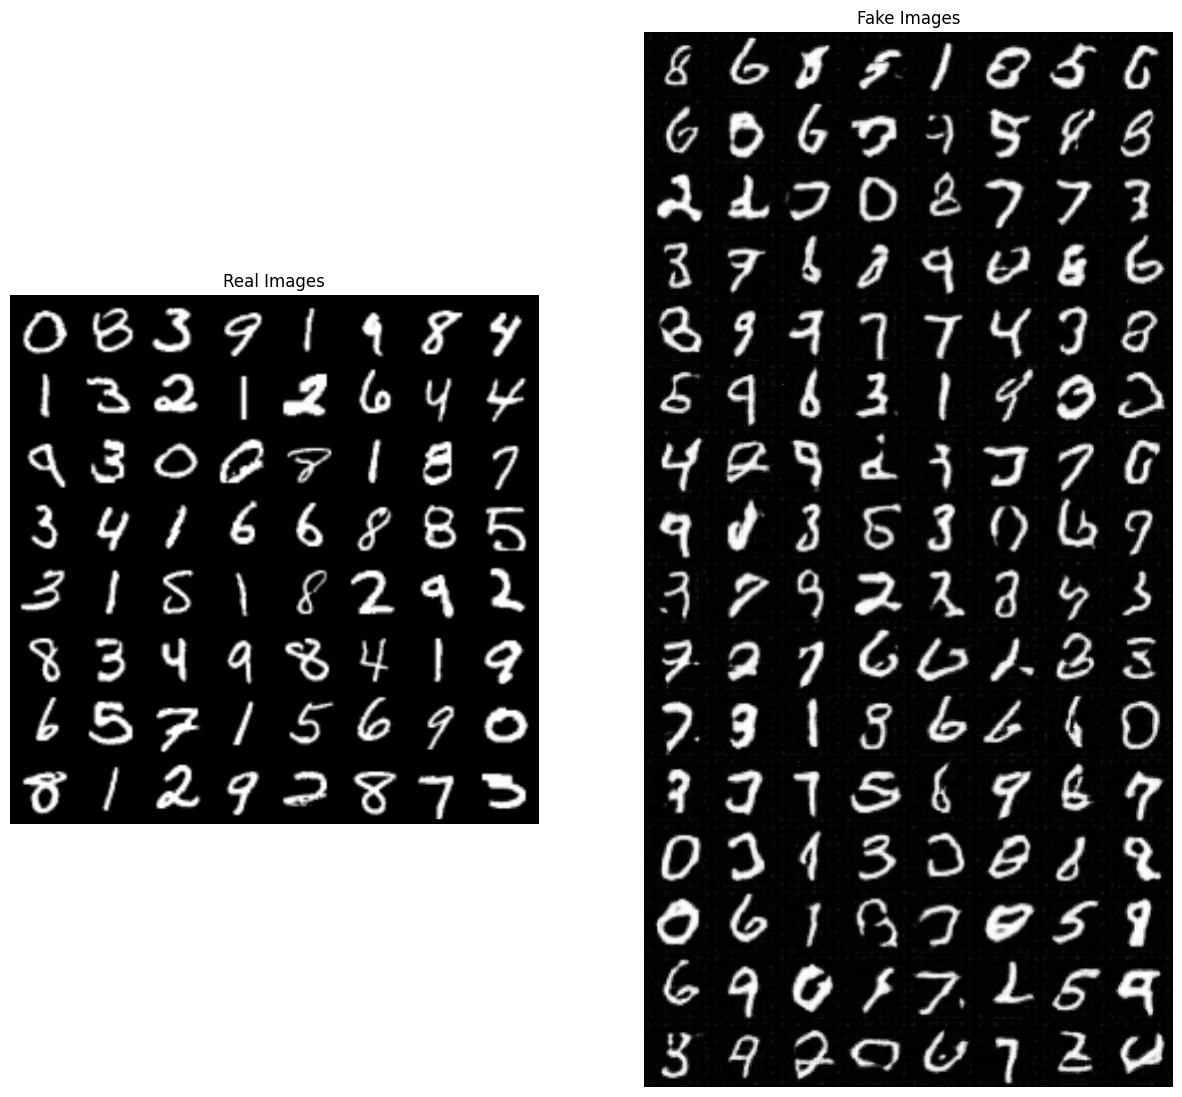

In [13]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

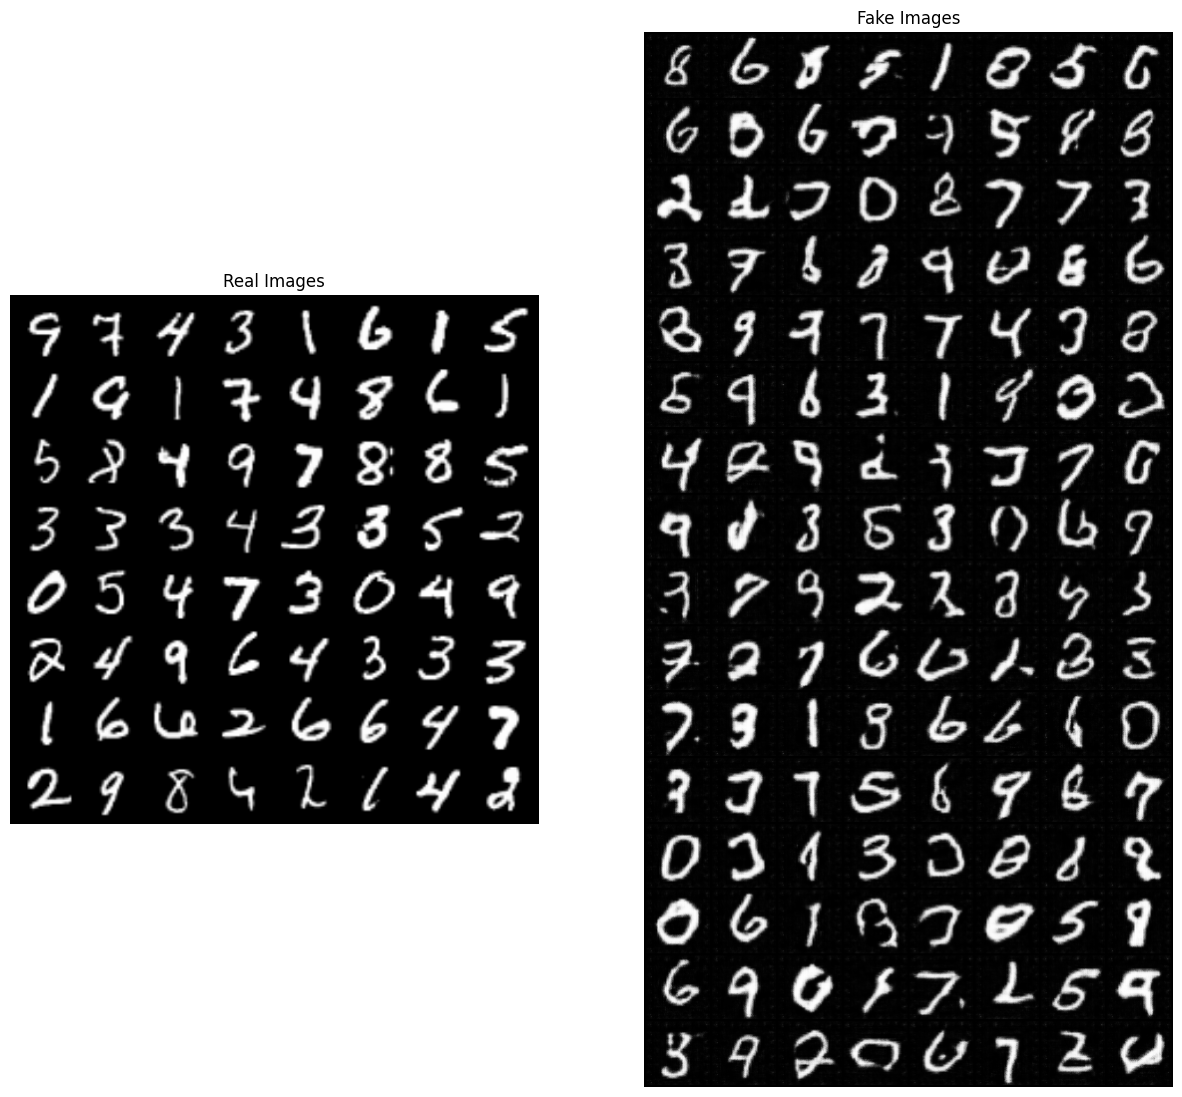

In [14]:
# Grab a batch of real images from the dataloader
real_batch = next(iter(dataloader))

# Plot the real images
plt.figure(figsize=(15,15))
plt.subplot(1,2,1)
plt.axis("off")
plt.title("Real Images")
plt.imshow(np.transpose(vutils.make_grid(real_batch[0].to(device)[:64], padding=5, normalize=True).cpu(),(1,2,0)))

# Plot the fake images from the last epoch
plt.subplot(1,2,2)
plt.axis("off")
plt.title("Fake Images")
plt.imshow(np.transpose(img_list[-1],(1,2,0)))
plt.show()

MovieWriter imagemagick unavailable; using Pillow instead.


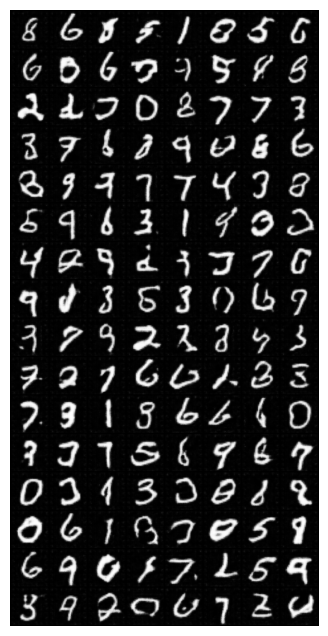

In [15]:
# Training loop (provided by the user) goes here...

# After training is done, visualize the generated images

fig = plt.figure(figsize=(8, 8))
plt.axis("off")
ims = [[plt.imshow(vutils.make_grid(img_list[i], padding=2, normalize=True).permute(1, 2, 0).cpu(), animated=True)] for i in range(len(img_list))]

ani = animation.ArtistAnimation(fig, ims, interval=500, repeat_delay=1000, blit=True)

# Save the animation as a gif
ani.save("dcgan_training.gif", writer='imagemagick')

# Show the animation
plt.show()